##ENTENDIMIENTO DE LOS DATOS



In [74]:
#Importar librerías

import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf, quarter_plot, month_plot

In [75]:
#Cargar los datos (no se puede hacer directamente con pandas)
"""
def leer_datos_consumo(archivo, hoja):


    # Cargar el workbook con openpyxl para manejar celdas fusionadas
    wb = openpyxl.load_workbook(archivo, data_only=True)
    ws = wb[hoja]

    # La tabla comienza en la fila 16 (encabezados) y 17 (datos)
    fila_inicio_datos = 17

    # Leer datos fila por fila
    datos = []

    for fila in range(fila_inicio_datos, ws.max_row + 1):
        # La fecha está en la columna B (columna 2), pero fusionada en B:D
        fecha = ws.cell(row=fila, column=2).value

        # Si no hay fecha, hemos llegado al final de los datos
        if fecha is None or not isinstance(fecha, str):
            break

        # Leer las 24 horas de consumo
        fila_datos = {'Fecha': fecha}

        # Mapeo de las columnas de horas
        columnas_horas = [
            5,   # H1 (E)
            7,   # H2 (G)
            8,   # H3 (H)
            9,   # H4 (I)
            12,  # H5 (L)
            14,  # H6 (N)
            16,  # H7 (P)
            21,  # H8 (U)
            22,  # H9 (V)
            23,  # H10 (W)
            24,  # H11 (X)
            25,  # H12 (Y)
            26,  # H13 (Z)
            27,  # H14 (AA)
            28,  # H15 (AB)
            29,  # H16 (AC)
            30,  # H17 (AD)
            31,  # H18 (AE)
            32,  # H19 (AF)
            33,  # H20 (AG)
            34,  # H21 (AH)
            35,  # H22 (AI)
            36,  # H23 (AJ)
            37,  # H24 (AK)
        ]

        # Leer cada hora
        for i, col in enumerate(columnas_horas, 1):
            valor = ws.cell(row=fila, column=col).value
            fila_datos[f'H{i}'] = valor  # Si es None, queda None

        # La columna total está en AL (38)
        total = ws.cell(row=fila, column=38).value
        fila_datos['Total'] = total  # Si es None, queda None

        datos.append(fila_datos)

    # Crear DataFrame
    df = pd.DataFrame(datos)

    # Convertir fecha a datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

    # Asegurar que las columnas de consumo sean numéricas
    columnas_numericas = [f'H{i}' for i in range(1, 25)] + ['Total']
    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    wb.close()

    return df


archivo1 = 'Consumos 2018-2020.xlsx'
archivo2 = 'Consumos 2023-2024.xlsx'
archivo3 = 'Consumos 2021-2022.xlsx'
archivo4 = 'Consumos 2025.xlsx'


#Leer las tres hojas con los consumos de las plantas (ENVIGADO, SAN DIEGO, ZAMORA) en todos los intervalos de tiempo
df_env1 = leer_datos_consumo(archivo1, 'METRO_ENV')
df_env2 = leer_datos_consumo(archivo2, 'METRO_ENV')
df_env3 = leer_datos_consumo(archivo3, 'METRO_ENV')
df_env4 = leer_datos_consumo(archivo4, 'METRO_ENV')

df_zamo1 = leer_datos_consumo(archivo1, 'METRO_ZAMO')
df_zamo2 = leer_datos_consumo(archivo2, 'METRO_ZAMO')
df_zamo3 = leer_datos_consumo(archivo3, 'METRO_ZAMO')
df_zamo4 = leer_datos_consumo(archivo4, 'METRO_ZAMO')

df_sand1 = leer_datos_consumo(archivo1, 'METRO_SAND')
df_sand2 = leer_datos_consumo(archivo2, 'METRO_SAND')
df_sand3 = leer_datos_consumo(archivo3, 'METRO_SAND')
df_sand4 = leer_datos_consumo(archivo4, 'METRO_SAND')

#Importar Serie


#Concatenar los dataframes

df_env = pd.concat([df_env1, df_env2, df_env3, df_env4], ignore_index=True)
df_zamo = pd.concat([df_zamo1, df_zamo2, df_zamo3, df_zamo4], ignore_index=True)
df_sand = pd.concat([df_sand1, df_sand2, df_sand3, df_sand4], ignore_index=True)"""

#df_env = df_env.sort_values("Fecha").reset_index(drop=True)
#df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
#df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)



df_env = pd.read_csv("dataframe_envigado.csv", index_col=0)
df_zamo = pd.read_csv("dataframe_zamora.csv", index_col=0)
df_sand = pd.read_csv("dataframe_sandiego.csv", index_col=0)


df_env = df_env.sort_values("Fecha").reset_index(drop=True)
df_sand = df_sand.sort_values("Fecha").reset_index(drop=True)
df_zamo = df_zamo.sort_values("Fecha").reset_index(drop=True)

df_env["Fecha"] = pd.to_datetime(df_env["Fecha"])
df_sand["Fecha"] = pd.to_datetime(df_sand["Fecha"])
df_zamo["Fecha"] = pd.to_datetime(df_zamo["Fecha"])


In [76]:
# Ordenar la serie


#Visualizar el dataset de ENVIGADO
df_zamo

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
0,2018-01-01,718.6672,726.0006,718.6671,722.3338,722.3336,1257.6672,2559.3338,2478.6671,2508.0003,...,2680.3339,2603.3339,2874.6674,2962.6673,2680.3341,2867.3341,2654.6676,2321.0008,861.6671,50072.0140
1,2018-01-02,832.3338,777.3338,810.3338,920.3338,2970.0008,4528.3341,5166.3346,5049.0013,4326.6678,...,4935.3346,5544.0011,5863.0014,5654.0013,4693.3343,4242.3345,3582.3343,3487.0009,2086.3339,90577.6890
2,2018-01-03,986.3338,1008.3339,993.6673,1008.3338,3208.3341,4902.3343,5551.3344,5408.3346,4777.6679,...,5016.0011,5247.0014,5808.0013,5665.0014,4891.3346,3813.3343,3487.0008,3215.6674,2053.3338,93408.3559
3,2018-01-04,1034.0003,927.6670,942.3338,975.3335,3028.6675,4664.0011,5195.6681,5335.0014,4730.0011,...,4818.0008,5276.3343,5844.6681,5679.6681,5016.0014,4125.0009,3483.3339,3300.0008,1936.0003,92077.3555
4,2018-01-05,1015.6671,971.6673,971.6671,924.0005,3058.0006,4700.6679,5320.3348,5404.6678,4689.6678,...,4682.3341,5408.3349,5386.3343,5804.3349,5228.6679,3967.3343,3384.3339,3102.0009,2123.0006,92524.6893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2917,2025-12-27,1048.4252,1072.6240,1038.3540,1261.3060,3859.8112,4967.5760,5139.8660,5285.2100,4534.5720,...,5592.8552,5434.5340,5012.5620,4710.2492,4520.7272,4157.9312,3559.5120,3482.9400,2020.0012,95642.0544
2918,2025-12-28,1086.3792,1029.1340,1035.1312,1123.8720,1731.3452,3056.3592,2988.6032,3044.8972,3077.7600,...,3564.3872,3484.0432,3623.0340,3961.4012,3719.0812,3600.3460,3607.8352,2928.2352,1413.9092,68599.0984
2919,2025-12-29,1184.4992,1223.1612,1259.8852,1455.7592,3994.7812,5112.1020,5219.7492,5311.8072,5023.0000,...,5356.6700,5583.9332,5958.6440,6057.6420,5309.6800,4388.7860,3861.7300,3462.4520,2187.9192,97647.7940
2920,2025-12-30,1144.8140,1082.1220,1033.8132,1071.4752,3757.8952,4720.9172,4967.6592,4910.3080,4659.4612,...,5478.1300,5372.2872,5615.5800,5933.3340,5276.4772,4193.7380,3813.8412,3195.4340,2072.6852,93933.1248


In [77]:
#Ver la información de cada columna del dataset (ENVIGADO)
df_zamo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Fecha   2922 non-null   datetime64[ns]
 1   H1      2922 non-null   float64       
 2   H2      2922 non-null   float64       
 3   H3      2922 non-null   float64       
 4   H4      2922 non-null   float64       
 5   H5      2922 non-null   float64       
 6   H6      2922 non-null   float64       
 7   H7      2922 non-null   float64       
 8   H8      2922 non-null   float64       
 9   H9      2922 non-null   float64       
 10  H10     2922 non-null   float64       
 11  H11     2922 non-null   float64       
 12  H12     2922 non-null   float64       
 13  H13     2922 non-null   float64       
 14  H14     2922 non-null   float64       
 15  H15     2922 non-null   float64       
 16  H16     2922 non-null   float64       
 17  H17     2922 non-null   float64       
 18  H18     

In [78]:
#Ver estadísticas descriptivas del dataset (ENVIGADO)
df_env.describe()

,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,...,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,2021-12-31 12:00:00,271.254787,252.883521,249.758709,299.813424,1559.407714,4266.145104,4819.732233,4740.257706,3997.470904,...,3918.052873,4393.832727,4596.194545,4422.017258,3780.571065,3099.862357,2588.717368,2152.006585,940.169942,68916.739426
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-01-01 06:00:00,205.333200,201.667200,201.666900,220.000100,1218.250525,3880.222725,4265.250700,4154.334025,3506.250800,...,3527.333825,4033.334000,3892.167625,3666.667125,3072.667400,2691.333950,2262.333600,1924.681850,766.360000,66396.004150
50%,2021-12-31 12:00:00,238.333700,234.667200,234.666900,271.333700,1635.333600,4568.667050,5445.001300,5393.668100,4335.834450,...,4109.641650,4766.667150,5085.667400,4876.667350,4086.500900,3223.000600,2585.001050,2222.000650,931.333600,75164.847950
75%,2023-12-31 18:00:00,284.891875,278.323700,274.990225,366.667200,1925.000300,5133.334000,5786.000750,5738.334000,4766.667800,...,4554.000600,5159.001150,5529.335125,5309.334250,4451.103200,3597.001050,2958.083525,2478.667100,1216.875200,78100.016800
max,2025-12-31 00:00:00,1818.667100,1738.000400,1763.667100,1180.667100,3666.667200,8169.335600,8609.335500,8635.002300,7252.668300,...,7003.335100,8231.669100,8712.002400,8466.335600,8407.668900,5551.334800,4620.000900,4165.334600,3043.334100,122503.366500
std,NaN,179.030590,140.005527,126.909259,130.479157,563.867367,1201.760686,1389.514652,1409.708707,1088.336183,...,978.099953,1173.319692,1297.422762,1237.198330,974.716355,690.780600,563.508302,498.858300,479.910122,15190.891829


**IMPORTANTE**: Analice los patrones interesantes que se vean en el describe y póngalos en contexto del problema que estamos abordando (ENVIGADO).

Hacer lo mismo para las otras dos plantas eléctricas (Sand Diego y Zamora)

In [79]:
#Pon tu código aquí

###Dimensiones de calidad

In [80]:
#Completetitud


# Columnas horarias
cols_horas = [f'H{i}' for i in range(1,25)]
# Se crea la lista de fechas deberia de comprender la columna 'Fecha'
rango_fechas = pd.date_range(
    start=df_env['Fecha'].min(),
    end=df_env['Fecha'].max(),
    freq='D'
)

#Se comparan las fechas que deberían de existir en en dataset con las que de verdad hay
fechas_faltantes = rango_fechas.difference(df_env['Fecha'])

print("Días faltantes:", len(fechas_faltantes))


Días faltantes: 0


In [81]:
#Conformidad o validez

negativos = (df_env[cols_horas] < 0).sum().sum()

print("Cantidad de registros negativos:", negativos)

Cantidad de registros negativos: 0


In [82]:
#Consistencia

df_env['suma_horas'] = df_env[cols_horas].sum(axis=1)

df_env['error_total'] = df_env['Total'] - df_env['suma_horas']

inconsistentes = df_env[np.abs(df_env['error_total']) > 1e-8]

print("Días inconsistentes:", len(inconsistentes))

df_env = df_env.drop(columns=['suma_horas', 'error_total'])

Días inconsistentes: 0


Si hay un cambio abructo entre horas:

(Ejemplo hipotetico de en la H12 el consumo sea mayor que la cota y en la H13 sea nulo)

Se puede cambiar la cota a conveniencia para encontrar cuantos candidatos pueden tener cambios abructos a considerar

In [83]:
#Precisión/Exactitud
cota = 2000

df_prueba = df_env.copy()

horas = [f"H{i}" for i in range(1, 25)]

mask = pd.Series(False, index=df_prueba.index)

for i in range(len(horas)-1):
    col_actual = horas[i]
    col_siguiente = horas[i+1]
    mask |= (df_prueba[col_actual] > cota) & (df_prueba[col_siguiente] == 0)

# Filtramos las filas que cumplen la condición
df_filtrado = df_prueba[mask]

print("Registor con posibilidad de cortos con una cota inferior de:", cota, 'son:', len(df_filtrado))

df_filtrado.tail(5)


Registor con posibilidad de cortos con una cota inferior de: 2000 son: 22


,Fecha,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,Total
939,2020-07-28,0.0000,366.6672,366.6672,0.0000,2200.0000,5500.0012,5866.6680,5500.0012,4766.6672,...,4766.6672,4400.0012,5500.0012,5866.6680,4400.0012,3666.6672,2933.3340,2200.0000,0.0,77000.0156
940,2020-07-29,366.6672,366.6672,366.6672,0.0000,2200.0000,5500.0012,5866.6680,5866.6680,5133.3340,...,4400.0012,4766.6672,5500.0012,5133.3340,4400.0012,4033.3340,2933.3340,2200.0000,0.0,78466.6832
976,2020-09-03,0.0000,366.6668,0.0000,366.6668,2200.0006,5500.0013,6233.3348,5500.0013,5133.3346,...,4766.6679,5133.3346,6233.3348,5133.3346,4400.0011,4033.3344,2933.3341,2200.0006,0.0,79933.3531
981,2020-09-08,0.0000,366.6668,366.6668,0.0000,1833.3339,5133.3346,5866.6680,5133.3346,5133.3346,...,4400.0012,4766.6679,3300.0008,3300.0008,3300.0008,3666.6676,2566.6673,2200.0006,0.0,71866.6847
984,2020-09-11,0.0000,366.6668,366.6668,0.0000,2200.0007,5500.0013,5866.6680,5866.6680,4766.6678,...,4766.6679,4766.6679,5500.0013,5500.0013,4033.3344,3666.6676,2933.3341,2200.0006,0.0,77733.3526


In [84]:
#Duplicidad (ya se verifica en completitud)

In [85]:
#Integridad (no creo que aplique y si lo hace ya se hizo en las anteriores)

In [86]:
#Detercción de outliers (univariados - poner, al menos, 3 métodos)

outliers_iqr_hora = {}

for col in cols_horas:

    Q1 = df_env[col].quantile(0.25)
    Q3 = df_env[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    mask = (df_env[col] < lim_inf) | (df_env[col] > lim_sup)

    outliers_iqr_hora[col] = mask.sum()

outliers_iqr_hora = pd.Series(outliers_iqr_hora)


print("\nTotal:", outliers_iqr_hora.sum())
outliers_iqr_hora


Total: 3730


,0
H1,284
H2,269
H3,250
H4,89
H5,49
H6,174
H7,73
H8,50
H9,52
H10,80


In [87]:
outliers_z_hora = {}

for col in cols_horas:

    mean = df_env[col].mean()
    std = df_env[col].std()

    z_scores = (df_env[col] - mean) / std

    mask = np.abs(z_scores) > 3

    outliers_z_hora[col] = mask.sum()

outliers_z_hora = pd.Series(outliers_z_hora)


print("\nTotal:", outliers_z_hora.sum())
outliers_z_hora


Total: 1026


,0
H1,77
H2,59
H3,60
H4,53
H5,3
H6,39
H7,33
H8,33
H9,34
H10,39


In [88]:
outliers_pct_hora = {}

for col in cols_horas:

    p1 = df_env[col].quantile(0.01)
    p99 = df_env[col].quantile(0.99)

    mask = (df_env[col] < p1) | (df_env[col] > p99)

    outliers_pct_hora[col] = mask.sum()

outliers_pct_hora = pd.Series(outliers_pct_hora)


print("\nTotal:", outliers_pct_hora.sum())
outliers_pct_hora



Total: 1284


,0
H1,30
H2,30
H3,30
H4,30
H5,60
H6,60
H7,60
H8,59
H9,60
H10,60


In [89]:
#Importancia de variables (cuando lo vemos de forma no contínua) - CONSULTAR

In [90]:
#Escalamiento - CONSULTAR (en caso de que aplique)

In [91]:
#Poner los datos de forma continua

def datos_continuos(
    df,
    fecha_col="Fecha",
    prefix_horas="H",
    n_horas=24
):
    """
    Convierte un dataframe en formato ancho (H1…H24) a serie de tiempo horaria.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.

    fecha_col : str
        Nombre de la columna de fecha.

    prefix_horas : str
        Prefijo de las columnas horarias (en nuestro caso 'H').

    n_horas : int
        Número de horas (default 24).

    """

    df = df.copy()

    # --- 1. Fecha a datetime ---
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    # --- 2. Columnas horarias ---
    cols_horas = [f"{prefix_horas}{i}" for i in range(1, n_horas + 1)]

    df_horas = df[[fecha_col] + cols_horas]

    # - Wide → Long ---
    df_long = df_horas.melt(
        id_vars=fecha_col,
        value_vars=cols_horas,
        var_name="Hora",
        value_name="Consumo"
    )

    # --- 4. Extraer hora numérica ---
    df_long["Hora"] = (
        df_long["Hora"].str.replace(prefix_horas, "", regex=False).astype(int)
    )

    # --- 5. Ajustar hora (H1 = 00:00) ---
    df_long["Hora"] = df_long["Hora"] - 1

    # --- 6. Crear datetime ---
    df_long["Datetime"] = (
        df_long[fecha_col] + pd.to_timedelta(df_long["Hora"], unit="h")
    )

    # --- 7. Indexar con la fecha + hora ---
    serie = (
        df_long.set_index("Datetime")["Consumo"].sort_index()
    )

    return serie

In [92]:
serie_envigado = datos_continuos(df_env)
serie_zamora = datos_continuos(df_zamo)
serie_sandiego = datos_continuos(df_sand)

serie_zamora.head(25)

,Consumo
Datetime,
2018-01-01 00:00:00,718.6672
2018-01-01 01:00:00,726.0006
2018-01-01 02:00:00,718.6671
2018-01-01 03:00:00,722.3338
2018-01-01 04:00:00,722.3336
2018-01-01 05:00:00,1257.6672
2018-01-01 06:00:00,2559.3338
2018-01-01 07:00:00,2478.6671
2018-01-01 08:00:00,2508.0003


###Visualización

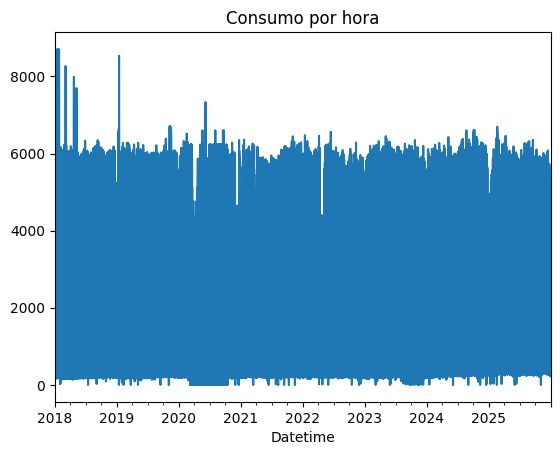

In [93]:
#Visualización por hora
serie_envigado = datos_continuos(df_env)
serie_envigado.plot(title = 'Consumo por hora')
plt.show()

In [94]:
#Visualización de los datos por día
consumo_diario_envigado = serie_envigado.resample('D').sum()
consumo_diario_envigado

,Consumo
Datetime,
2018-01-01,35079.0064
2018-01-02,69230.3502
2018-01-03,70323.0178
2018-01-04,69131.3509
2018-01-05,70741.0171
...,...
2025-12-27,66398.7078
2025-12-28,41106.6061
2025-12-29,66604.6776


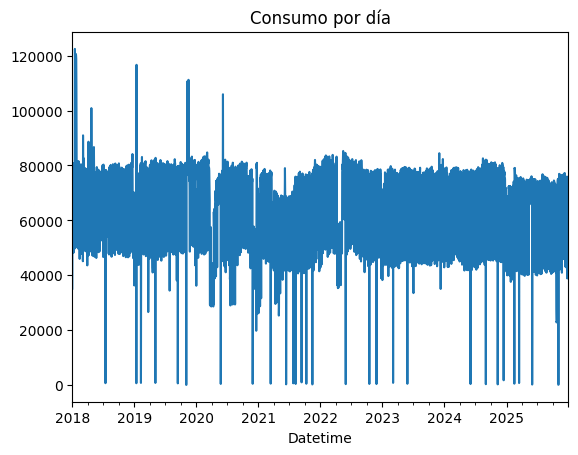

In [95]:
consumo_diario_envigado.plot(title = 'Consumo por día')
plt.show()

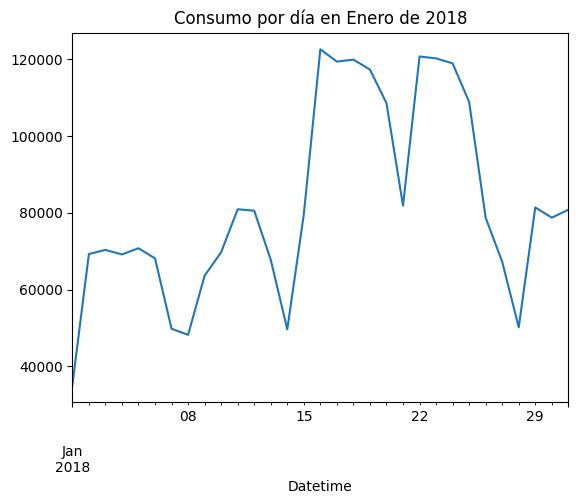

In [96]:
#Visualizar por hora durante un mes particular (enero)
consumo_diario_envigado.loc[(consumo_diario_envigado.index.month == 1) & (consumo_diario_envigado.index.year == 2018)].plot(title = 'Consumo por día en Enero de 2018')
plt.show()

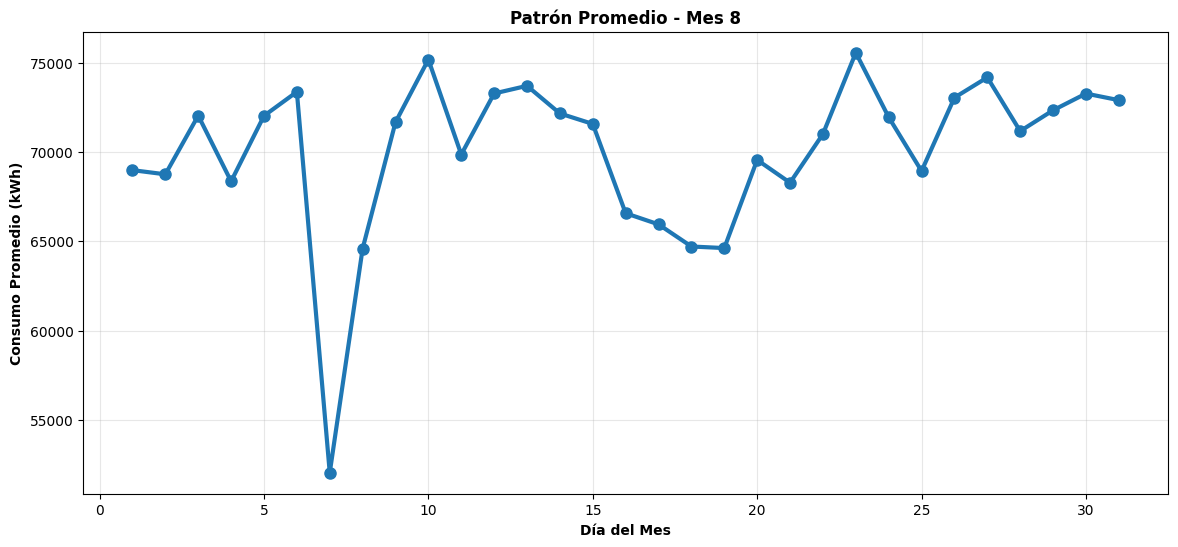

In [97]:
#Comportamiento general de un més particular durante la serie

mes = 8  # Cambia el mes aquí

#Filtrar solo el mes que queremos analizar
df_temp = df_env[df_env['Fecha'].dt.month == mes].copy()

#Extraer el día del mes (1-31)
df_temp['Día'] = df_temp['Fecha'].dt.day

# Promedio por día del mes
datos = df_temp.groupby('Día')['Total'].mean()

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(datos.index, datos.values, marker='o', linewidth=3, markersize=8)
plt.xlabel('Día del Mes', fontweight='bold')
plt.ylabel('Consumo Promedio (kWh)', fontweight='bold')
plt.title(f'Patrón Promedio - Mes {mes}', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

**Importente:** Graficar consumos en varios meses, semanas, años, y también con otras escalas como por día, semana, etc, todo con su respectiva interpretación. También, le pueden poner sus promedios móviles.

In [98]:
#Visualización de los datos por semana
consumo_semanal_envigado = serie_envigado.resample('W').sum()
consumo_semanal_envigado

,Consumo
Datetime,
2018-01-07,432417.4377
2018-01-14,460331.7831
2018-01-21,748755.5228
2018-01-28,664480.8347
2018-02-04,515056.7914
...,...
2025-12-07,524003.2187
2025-12-14,488567.3028
2025-12-21,483961.1260


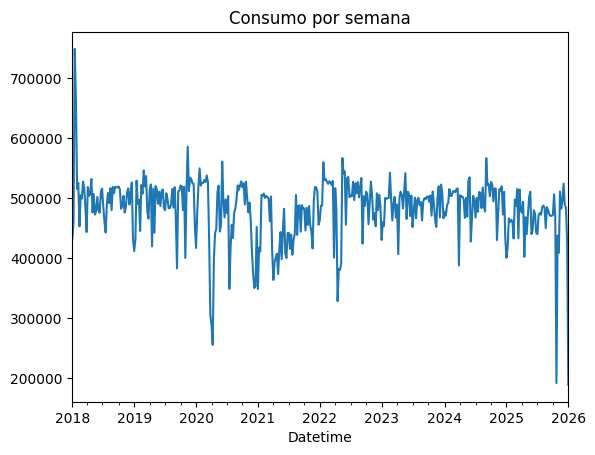

In [99]:
consumo_semanal_envigado.plot(title = 'Consumo por semana')
plt.show()

Existen diferentes ventanas temporales:

* B = día hábil

* D = día calendario

* W = semanal

* M = fin de mes

* BM = fin de mes hábil

* MS = inicio de mes

* BMS = inicio de mes hábil

* Q = fin de trimestre

* BQ = fin de trimestre hábil

* QS = inicio de trimestre

* BQS = inicio de trimestre hábil

* A = fin de año

* BA = fin de año hábil

* AS = inicio de año

* BAS = inicio de año hábil

* h = por hora

* min = por minuto

* s = por segundo

* ms = milisegundos

* us = microsegundos



In [100]:
#Visualización de los datos por mes

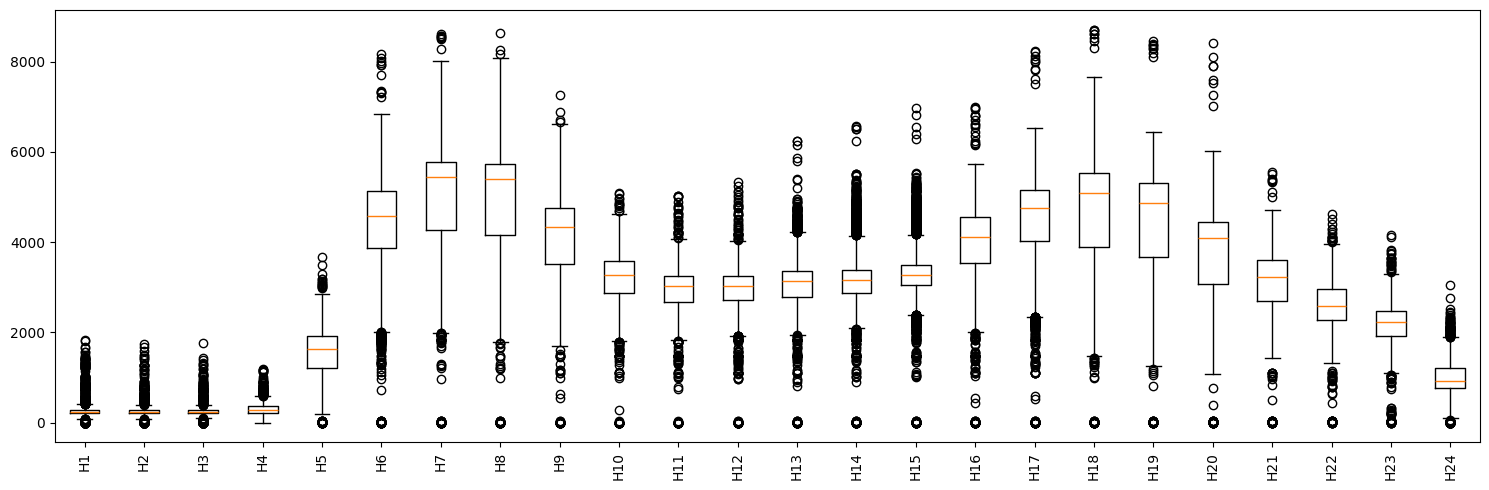

In [101]:
#Hacer un boxplot para cada columna

cols_horas = [f'H{i}' for i in range(1,25)]

plt.figure(figsize=(15,5))
plt.boxplot([df_env[col] for col in cols_horas])
plt.xticks(range(1,25), cols_horas, rotation=90)
plt.tight_layout()
plt.show()

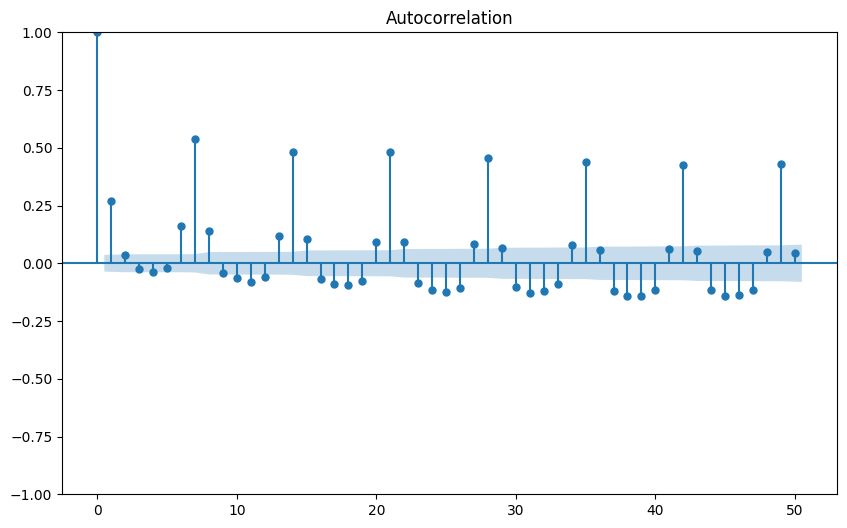

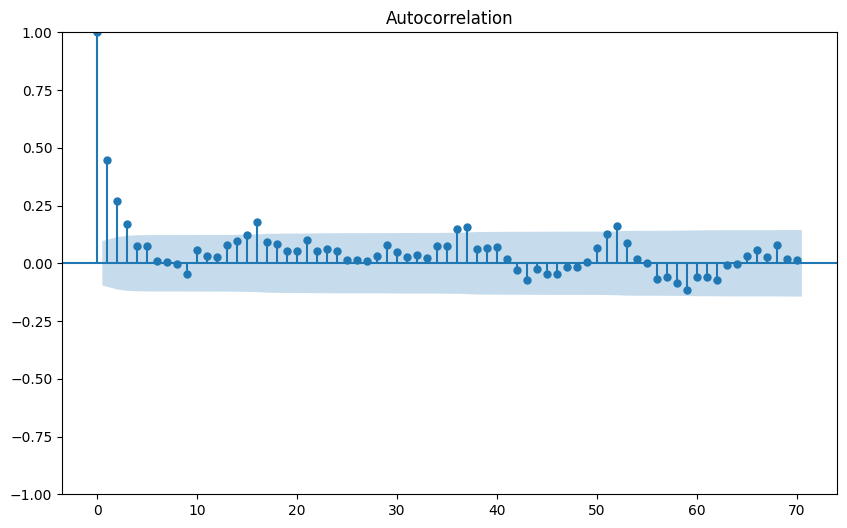

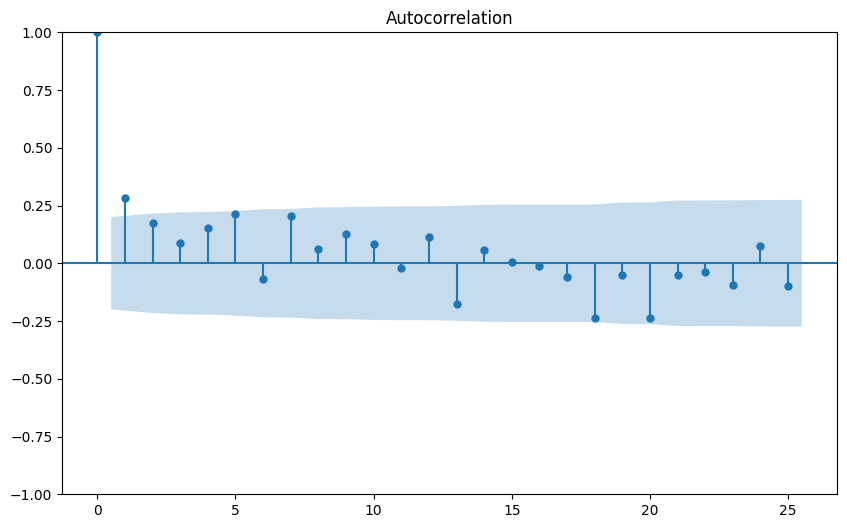

In [102]:
#Diagrama de autocorrelación

fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_diario_envigado, lags = 50, ax = ax)
plt.show()



fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_semanal_envigado, lags = 70, ax = ax)
plt.show()


consumo_mensual_envigado = serie_envigado.resample('ME').sum()

fig, ax = plt.subplots(figsize = (10,6))
plot_acf(consumo_mensual_envigado, lags = 25, ax = ax)
plt.show()

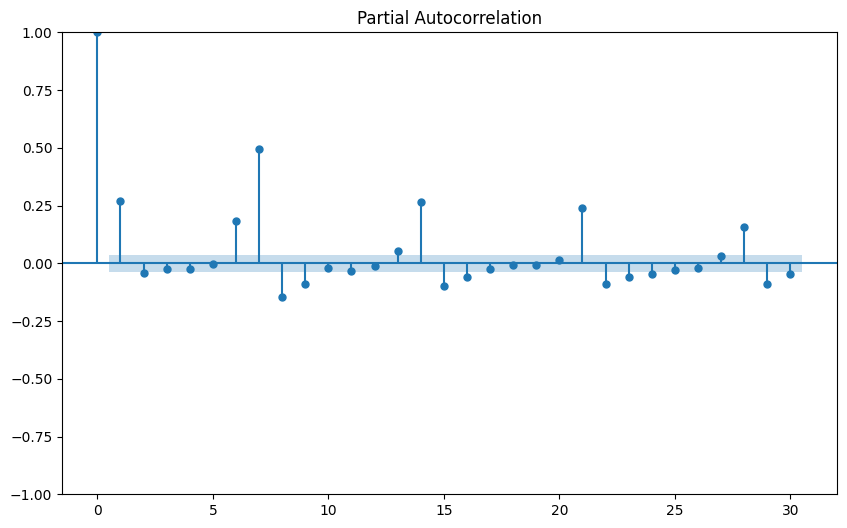

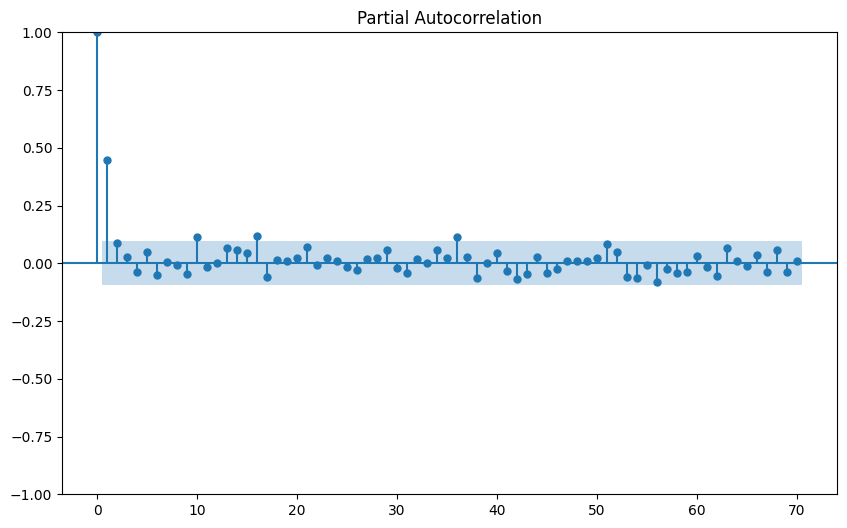

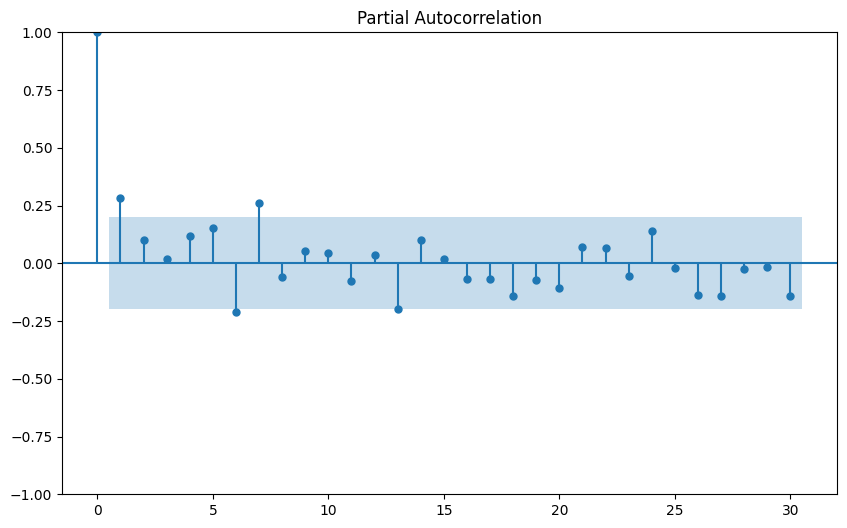

In [103]:
#Diagrama de autocorrelación parcial

fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_diario_envigado, lags = 30, ax = ax)
plt.show()


fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_semanal_envigado, lags = 70, ax = ax)
plt.show()


fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(consumo_mensual_envigado, lags = 30, ax = ax)
plt.show()

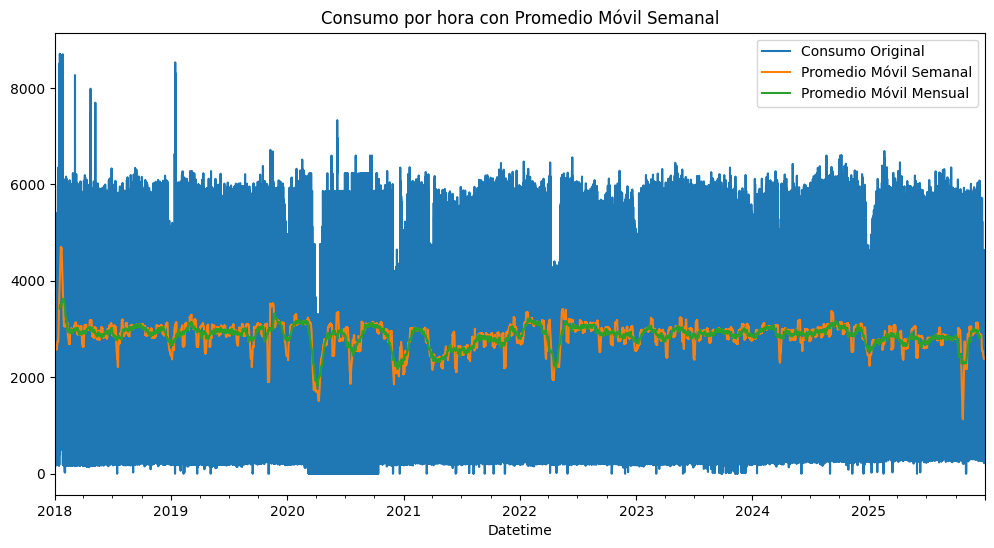

In [104]:
#Promedio móvil (hacerlo con varias ventanas de tiempo)

# Calcular el promedio móvil directamente sobre la serie. Un promedio semanal requiere 7*24 horas.
rolling_mean_semanal = serie_envigado.rolling(window=7*24, center=True).mean()
rolling_mean_mesual = serie_envigado.rolling(window=30*24, center=True).mean()


# Crear un DataFrame para plotear tanto la serie original como el promedio móvil
df_plot_rolling = pd.DataFrame({
    'Consumo Original': serie_envigado,
    'Promedio Móvil Semanal': rolling_mean_semanal,
    'Promedio Móvil Mensual': rolling_mean_mesual
})

df_plot_rolling.plot(title='Consumo por hora con Promedio Móvil Semanal', figsize=(12, 6))
plt.show()

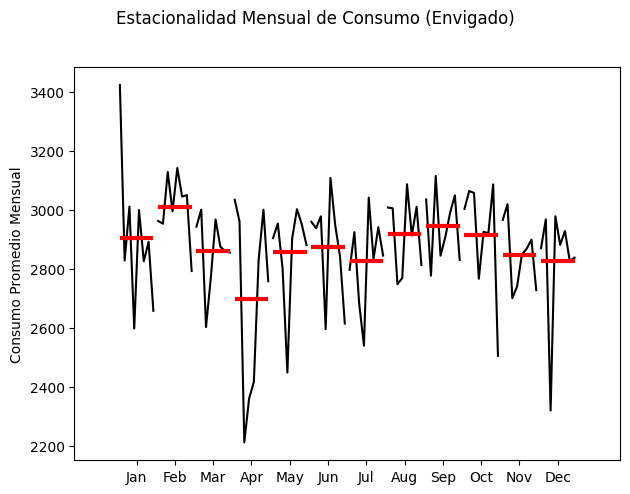

In [105]:
#Graficas de estacionalidad (Hacerlo con varias escalas como hora, días, semanas y meses)

# 1. Estacionalidad mensual
# Resample a promedio mensual y luego plotear
fig_month = month_plot(serie_envigado.resample('ME').mean(), ylabel='Consumo Promedio Mensual')
fig_month.suptitle('Estacionalidad Mensual de Consumo (Envigado)', y=1.02)
plt.tight_layout()
plt.show()

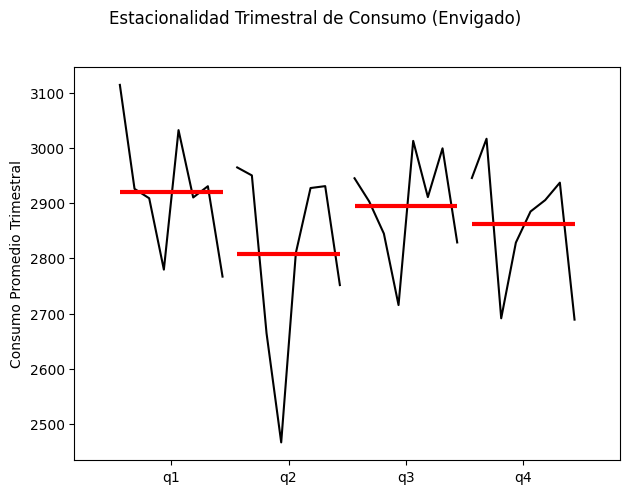

In [106]:
# 2. Estacionalidad trimestral

# Resample a promedio trimestral (inicio del trimestre) y luego plotear
fig_quarter = quarter_plot(serie_envigado.resample('QS').mean(), ylabel='Consumo Promedio Trimestral')
fig_quarter.suptitle('Estacionalidad Trimestral de Consumo (Envigado)', y=1.02)
plt.tight_layout()
plt.show()

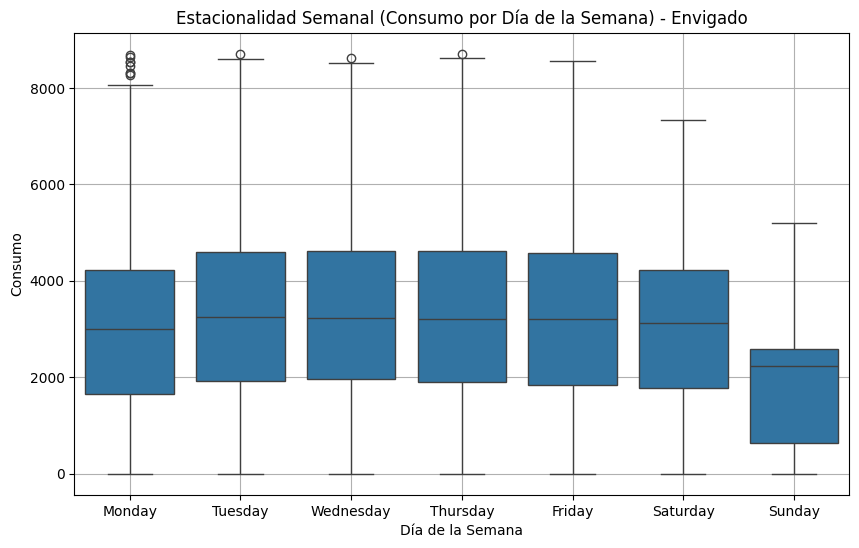

In [107]:
# Convertir la serie a DataFrame para facilitar la extracción de componentes de tiempo
df_temp = serie_envigado.copy().to_frame(name='Consumo')
df_temp['Dia_Semana'] = df_temp.index.day_name()
df_temp['Hora_Dia'] = df_temp.index.hour

# 3. Estacionalidad semanal (por día de la semana)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dia_Semana', y='Consumo', data=df_temp, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Estacionalidad Semanal (Consumo por Día de la Semana) - Envigado')
plt.xlabel('Día de la Semana')
plt.ylabel('Consumo')
plt.grid(True)
plt.show()

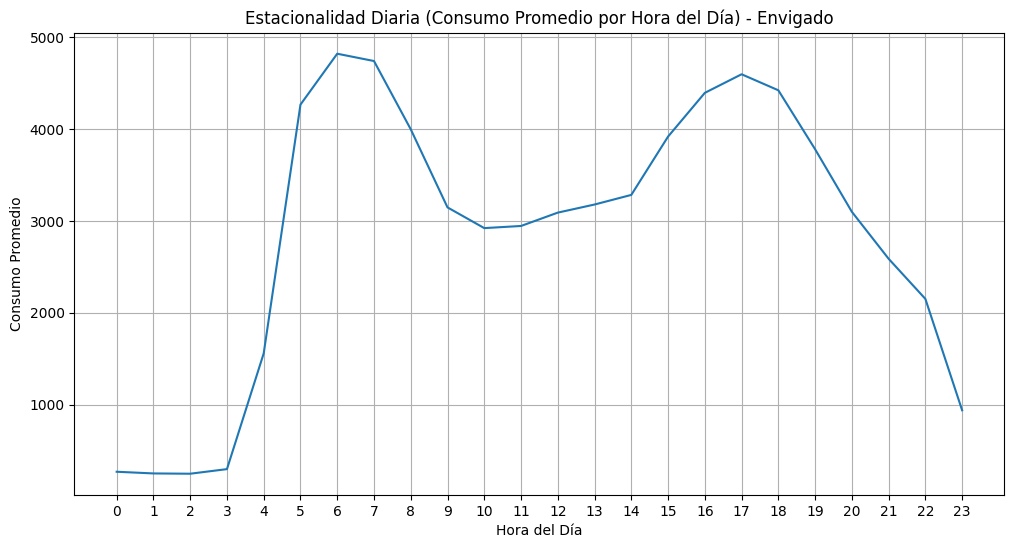

In [108]:
# 4. Estacionalidad diaria (por hora del día)
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hora_Dia', y='Consumo', data=df_temp, estimator=np.mean, errorbar=None)
plt.title('Estacionalidad Diaria (Consumo Promedio por Hora del Día) - Envigado')
plt.xlabel('Hora del Día')
plt.ylabel('Consumo Promedio')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [109]:
#Descomposición estacional





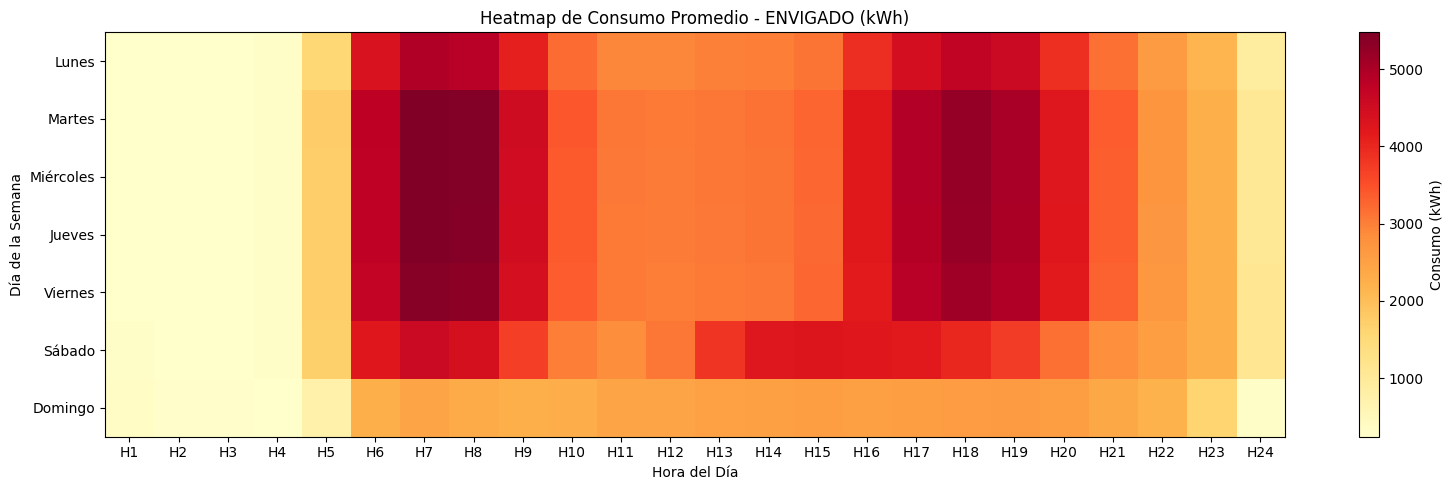

In [110]:
#Visualizaciones adicionales (diagramas de calor, etc)

#Diagrama de calor

cols_horas = [f'H{i}' for i in range(1,25)]

# Asegurar fecha en formato datetime
df = df_env.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Día de la semana (0=Lunes ... 6=Domingo)
df['dow'] = df['Fecha'].dt.dayofweek

# Promedio por día de semana
prom = df.groupby('dow')[cols_horas].mean()

# Orden y nombres bonitos
nombres = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
prom.index = [nombres[i] for i in prom.index]
prom = prom.reindex(nombres)  # fuerza orden Lunes..Domingo

# Heatmap
plt.figure(figsize=(16,5))
plt.imshow(prom.values, aspect='auto', origin='upper', cmap='YlOrRd')
plt.colorbar(label='Consumo (kWh)')
plt.xticks(range(24), cols_horas, rotation=0)
plt.yticks(range(7), nombres)
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.title('Heatmap de Consumo Promedio - ENVIGADO (kWh)')
plt.tight_layout()
plt.show()

Análisis multi-serie

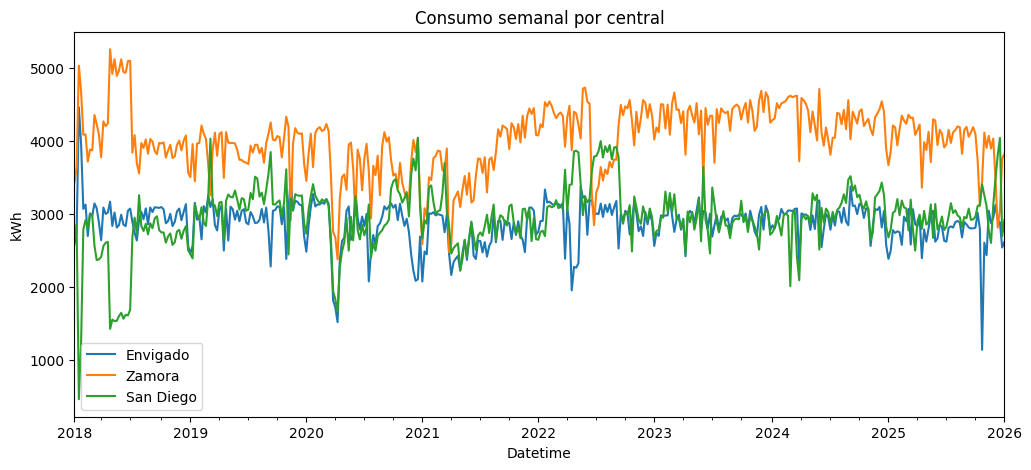

In [111]:
# ---- elegir periodicidad ----
periodicidad = "W"   # "H"=hora, "D"=día, "W"=semana, "M"=mes

# ---- juntar series ----
df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df.columns = ["Envigado", "Zamora", "San Diego"]

# ---- re-muestrear ----
df_p = df.resample(periodicidad).mean()

# ---- gráfica ----
df_p.plot(figsize=(12,5))
plt.title("Consumo semanal por central")
plt.ylabel("kWh")
plt.show()



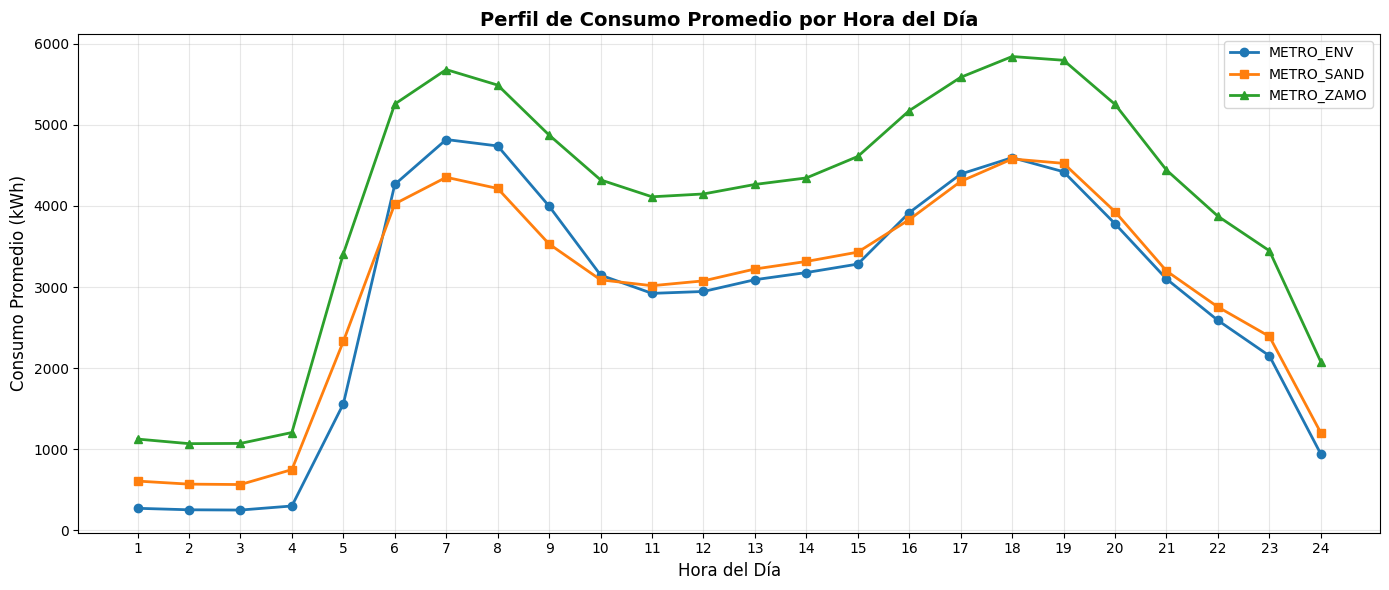

In [112]:
columnas_horas = [f'H{i}' for i in range(1, 25)]
consumo_promedio_hora_env = df_env[columnas_horas].mean()
consumo_promedio_hora_sand = df_sand[columnas_horas].mean()
consumo_promedio_hora_zamo = df_zamo[columnas_horas].mean()

fig, ax = plt.subplots(figsize=(14, 6))
horas = range(1, 25)

ax.plot(horas, consumo_promedio_hora_env, marker='o', label='METRO_ENV', linewidth=2)
ax.plot(horas, consumo_promedio_hora_sand, marker='s', label='METRO_SAND', linewidth=2)
ax.plot(horas, consumo_promedio_hora_zamo, marker='^', label='METRO_ZAMO', linewidth=2)

ax.set_title('Perfil de Consumo Promedio por Hora del Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Consumo Promedio (kWh)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 25))

plt.tight_layout()
plt.show()

/tmp/ipython-input-770501354.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_p = df.resample(periodicidad).sum()


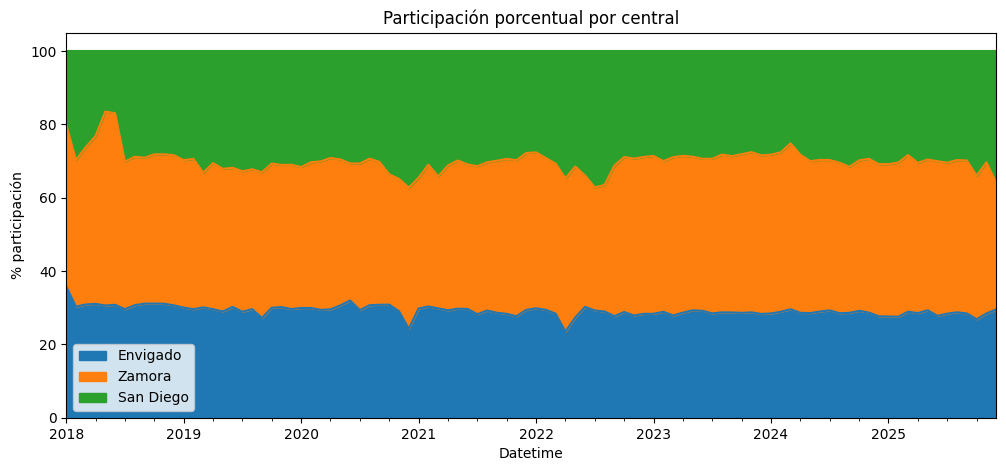

In [113]:
periodicidad = "M"   # cambiar aquí


df.columns = ["Envigado", "Zamora", "San Diego"]

df_p = df.resample(periodicidad).sum()

# porcentaje
df_pct = df_p.div(df_p.sum(axis=1), axis=0) * 100

# gráfica
df_pct.plot.area(figsize=(12,5))
plt.title("Participación porcentual por central")
plt.ylabel("% participación")
plt.show()


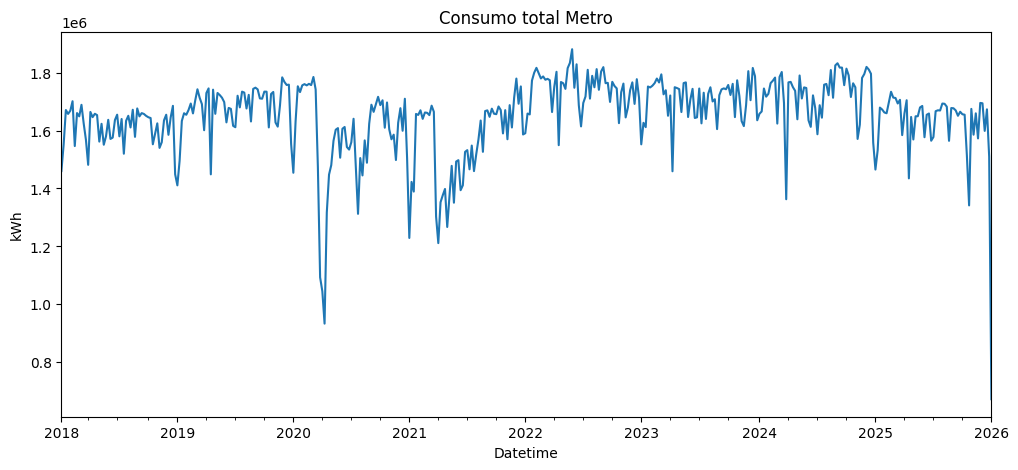

In [114]:
periodicidad = "W"

df_total = (
    serie_envigado +
    serie_zamora +
    serie_sandiego
)

df_total_p = df_total.resample(periodicidad).sum()

df_total_p.plot(figsize=(12,5))
plt.title("Consumo total Metro")
plt.ylabel("kWh")
plt.show()

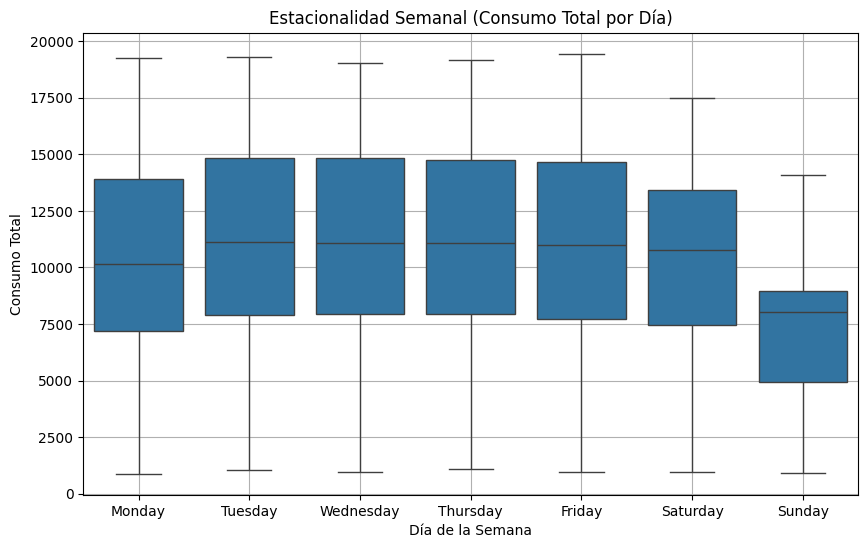

In [115]:


# --- Serie total (suma) ---
serie_total = df.sum(axis=1)

# --- Convertir a DataFrame temporal ---
df_temp = serie_total.to_frame(name="Consumo")

df_temp["Dia_Semana"] = df_temp.index.day_name()
df_temp["Hora_Dia"] = df_temp.index.hour

# --- Orden correcto ---
orden = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

# --- Boxplot estilo presentación ---
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Dia_Semana",
    y="Consumo",
    data=df_temp,
    order=orden
)

plt.title("Estacionalidad Semanal (Consumo Total por Día)")
plt.xlabel("Día de la Semana")
plt.ylabel("Consumo Total")
plt.grid(True)

plt.show()

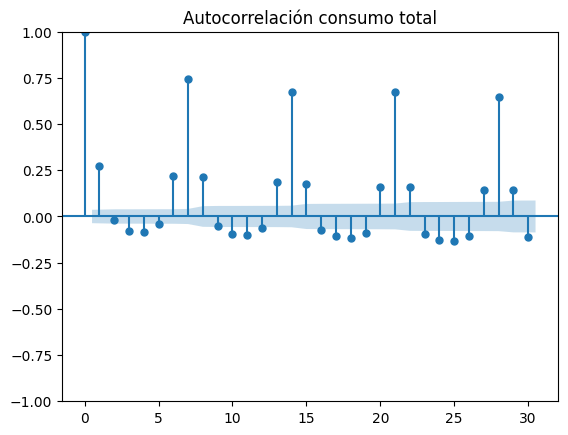

In [116]:
periodicidad = "D"
lags = 30   # ← cantidad de rezagos que quieres ver

df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df_total = df.sum(axis=1)

serie_p = df_total.resample(periodicidad).mean()

plot_acf(serie_p, lags=lags)

plt.title("Autocorrelación consumo total")
plt.show()

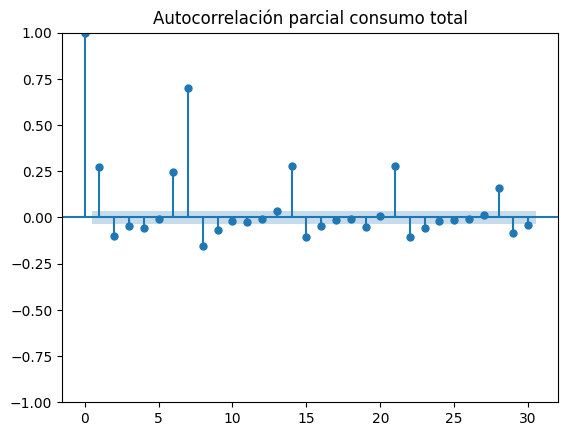

In [117]:
# ---- parámetros ----
periodicidad = "D"
lags = 30

# ---- unir centrales ----
df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

# ---- serie total ----
df_total = df.sum(axis=1)

serie_p = df_total.resample(periodicidad).sum()

# ---- PACF ----
plot_pacf(
    serie_p,
    lags=lags,
    method="ywm"   # método estable
)

plt.title("Autocorrelación parcial consumo total")
plt.show()


/tmp/ipython-input-1508183844.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_p = df.resample(periodicidad).mean()


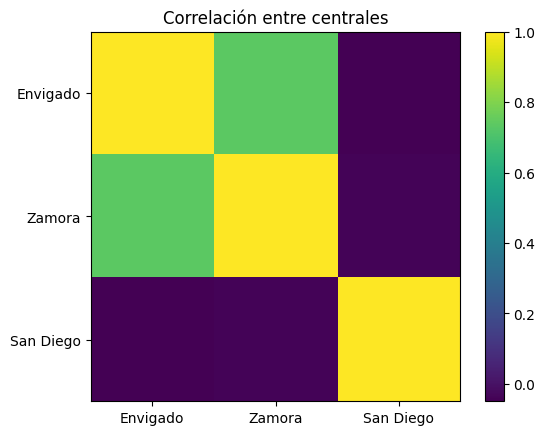

In [118]:
periodicidad = "Y"

df = pd.concat(
    [serie_envigado, serie_zamora, serie_sandiego],
    axis=1
)

df.columns = ["Envigado", "Zamora", "San Diego"]

df_p = df.resample(periodicidad).mean()

corr = df_p.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)
plt.title("Correlación entre centrales")
plt.show()
